# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


In [3]:
# Task 1
import pandas as pd
import plotly.express as px

# 1. Load the dataset
df = pd.read_csv('../data/netflix_catalogue.csv')

df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

valid_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
df_filtered = df[df['rating'].isin(valid_ratings)]

heatmap_data = df_filtered.groupby(['rating', 'decade']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(['TV-14', 'TV-MA', 'PG-13', 'R', 'PG'])    
fig = px.imshow(
    heatmap_data,
    text_auto=True,
    color_continuous_scale='Blues',
    title="TV-MA Dominates 2000s & 2010s, While TV-14 Leads in 2020s",
    labels=dict(x="Decade", y="Content Rating", color="Count")
)

fig.update_layout(
    xaxis_title="Decade",
    yaxis_title="Content Rating",
    title_font=dict(size=16, family="Arial")
)

fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


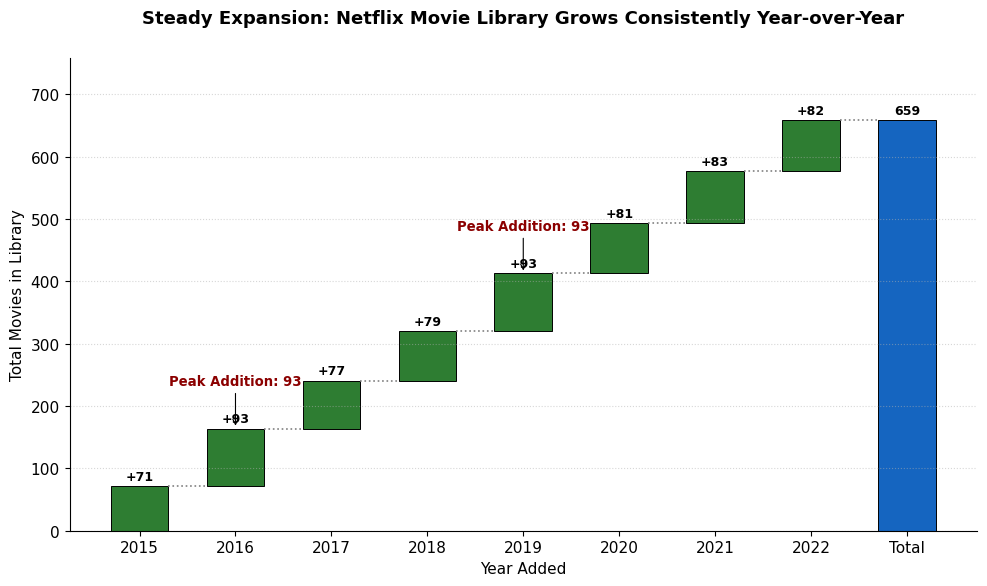

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and filter the data
df = pd.read_csv('../data/netflix_catalogue.csv')
movies_df = df[(df['type'] == 'Movie') & (df['added_year'] >= 2015) & (df['added_year'] <= 2022)]

# 2. Group by year and count
yearly_counts = movies_df.groupby('added_year').size().reset_index(name='count')
years = yearly_counts['added_year'].astype(str).tolist()
counts = yearly_counts['count'].tolist()
total = sum(counts)

# 3. Prepare data for the waterfall structure
x_labels = years + ['Total']
bottoms = [0] + list(np.cumsum(counts)[:-1]) + [0]
heights = counts + [total]
colors = ['#2e7d32'] * len(years) + ['#1565c0']  # Green for additions, Blue for total

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.6
bars = ax.bar(x_labels, heights, bottom=bottoms, width=width, color=colors, edgecolor='black', linewidth=0.7)

# Add dotted connecting lines between consecutive bars
for i in range(len(x_labels) - 1):
    right_edge = i + width / 2
    left_edge_next = i + 1 - width / 2
    height_level = bottoms[i] + heights[i] if i < len(years) else total
    if i == len(years) - 1:
        height_level = bottoms[i] + heights[i]
    ax.plot([right_edge, left_edge_next], [height_level, height_level], color='gray', linestyle=':', linewidth=1.2)

# Add values above/on the bars
for i, bar in enumerate(bars):
    val = heights[i]
    if i < len(years):
        label = f"+{val}"
        y_pos = bottoms[i] + val + 5
    else:
        label = f"{val}"
        y_pos = val + 5
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Annotations for the peak addition years (2016 & 2019 tie)
ax.annotate('Peak Addition: 93', xy=(1, bottoms[1] + heights[1]), xytext=(1, bottoms[1] + heights[1] + 70),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=0.8), ha='center', fontsize=9.5, fontweight='bold', color='darkred')

ax.annotate('Peak Addition: 93', xy=(4, bottoms[4] + heights[4]), xytext=(4, bottoms[4] + heights[4] + 70),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=0.8), ha='center', fontsize=9.5, fontweight='bold', color='darkred')

# 6. Formatting and Insight Title
ax.set_title("Steady Expansion: Netflix Movie Library Grows Consistently Year-over-Year", fontsize=13, fontweight='bold', pad=25)
ax.set_ylabel("Total Movies in Library", fontsize=11)
ax.set_xlabel("Year Added", fontsize=11)
ax.set_ylim(0, total + 100)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Styling clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('netflix_waterfall.png', dpi=300)